<a href="https://colab.research.google.com/github/melia1702/Pertemuan-keenam/blob/main/Prakitkum_6_3_MG_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


PRAKTIKUM 6.3: MOTION BLUR ESTIMATION DAN DEBLURRING
True Blur Parameters: Length = 21, Angle = 30°
Estimated Parameters: Length = 127, Angle = 81.0°
Iteration 5: MSE = 85.44
Iteration 10: MSE = 74.43
Iteration 15: MSE = 69.08
Iteration 20: MSE = 65.94


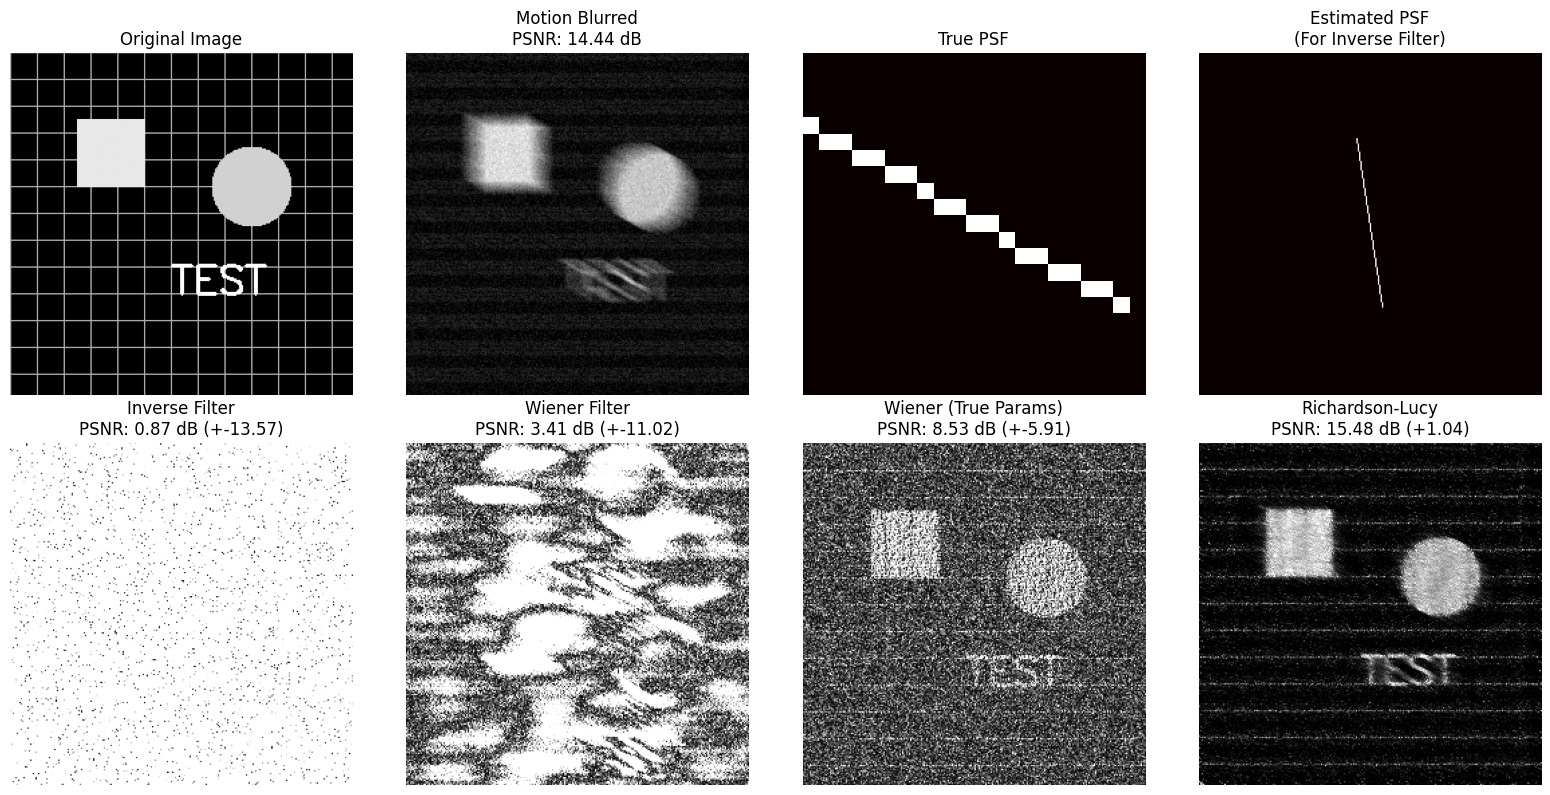


DEBLURRING PERFORMANCE COMPARISON
--------------------------------------------------------------------------------
Method                    PSNR (dB)    Improvement (dB) SSIM         MSE         
--------------------------------------------------------------------------------
Inverse Filter            0.87         -13.57          0.015        53266.13    
Wiener Filter             3.41         -11.02          0.005        29627.88    
Wiener (True Params)      8.53         -5.91           0.008        9128.53     
Richardson-Lucy           15.48        1.04            0.199        1843.11     

FREQUENCY SPECTRUM ANALYSIS
----------------------------------------


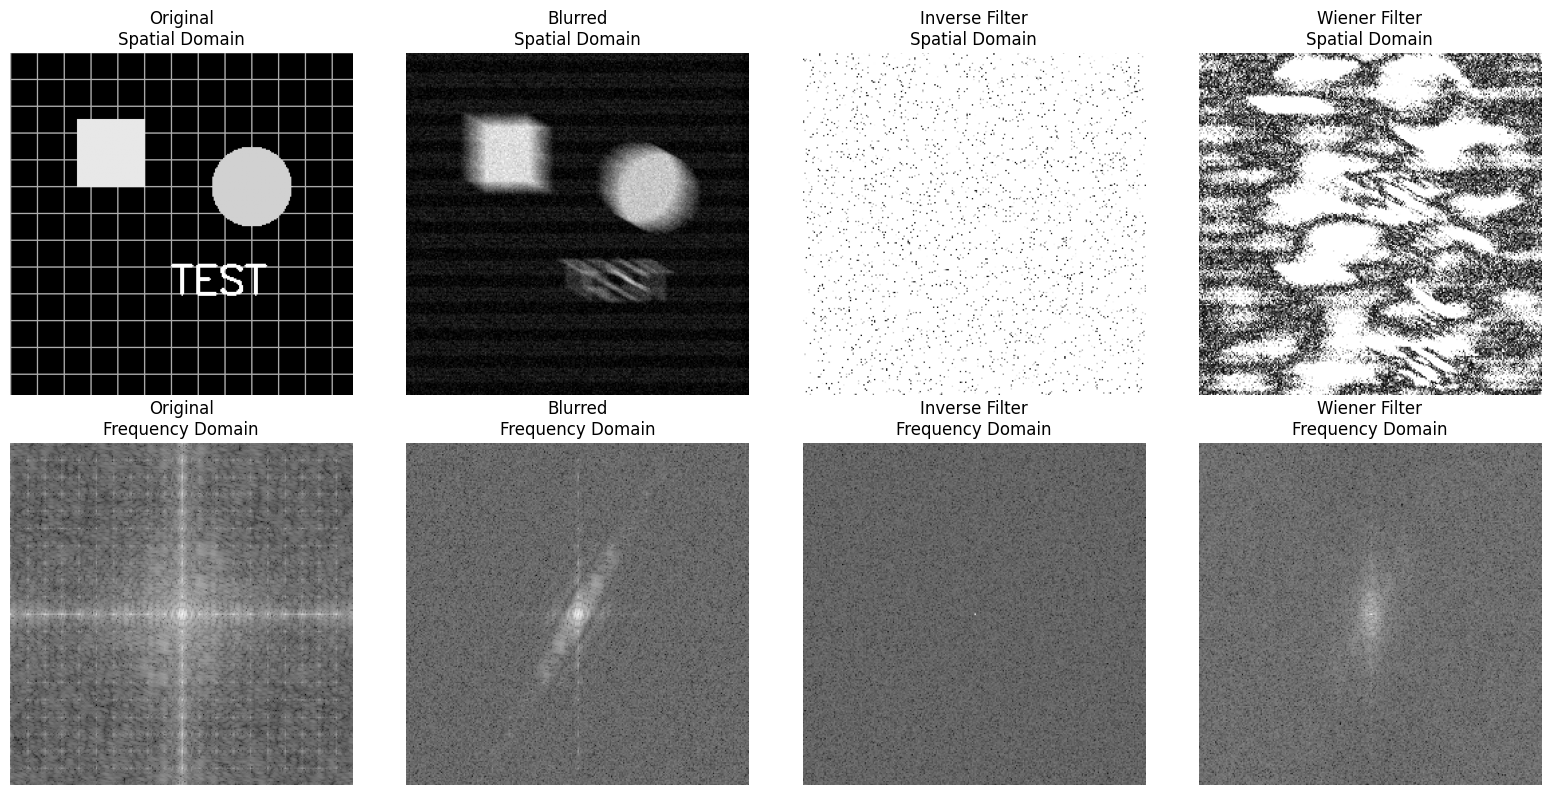


INTENSITY PROFILE ANALYSIS
----------------------------------------


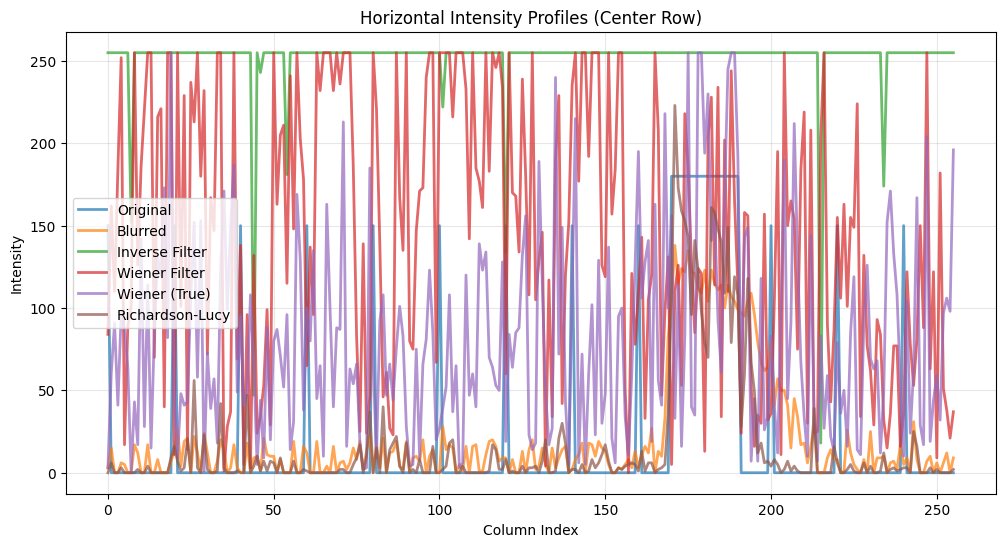

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft2, ifft2, fftshift, ifftshift

def praktikum_6_3():
    """
    Motion blur estimation dan teknik deblurring
    """
    print("\nPRAKTIKUM 6.3: MOTION BLUR ESTIMATION DAN DEBLURRING")
    print("=" * 60)

    # Generate motion blurred image
    def create_motion_blurred_image():
        """Create image with simulated motion blur"""
        # Load or create test image
        img = np.zeros((256, 256), dtype=np.uint8)

        # Create detailed pattern
        for i in range(0, 256, 20):
            cv2.line(img, (i, 0), (i, 255), 150, 1)
            cv2.line(img, (0, i), (255, i), 150, 1)

        # Add objects
        cv2.rectangle(img, (50, 50), (100, 100), 200, -1)
        cv2.circle(img, (180, 100), 30, 180, -1)

        # Text for high frequency content
        cv2.putText(img, 'TEST', (120, 180), cv2.FONT_HERSHEY_SIMPLEX,
                   1, 220, 2)

        # Create motion blur PSF
        length = 21
        angle = 30  # degrees

        psf = np.zeros((length, length))
        center = length // 2
        angle_rad = np.deg2rad(angle)

        # Draw line for motion blur
        x_start = int(center - (length/2) * np.cos(angle_rad))
        y_start = int(center - (length/2) * np.sin(angle_rad))
        x_end = int(center + (length/2) * np.cos(angle_rad))
        y_end = int(center + (length/2) * np.sin(angle_rad))

        cv2.line(psf, (x_start, y_start), (x_end, y_end), 1, 1)
        psf = psf / np.sum(psf)

        # Apply motion blur
        blurred = cv2.filter2D(img.astype(float), -1, psf)

        # Add noise
        noise = np.random.normal(0, 10, blurred.shape)
        blurred_noisy = np.clip(blurred + noise, 0, 255)

        return img, blurred_noisy.astype(np.uint8), psf

    # Motion blur parameter estimation
    def estimate_motion_blur_parameters(image):
        """
        Estimate motion blur length and angle from image
        using Radon transform or Hough transform
        """
        # Convert to binary edge image
        edges = cv2.Canny(image, 50, 150)

        # Method 1: Using Hough Line Transform
        lines = cv2.HoughLines(edges, 1, np.pi/180, threshold=100)

        angles = []
        if lines is not None:
            for line in lines[:5]:  # Take top 5 lines
                rho, theta = line[0]
                angles.append(np.degrees(theta))

        # Method 2: Using image spectrum (cepstrum analysis)
        # Compute log spectrum
        f = np.fft.fft2(image.astype(float))
        fshift = np.fft.fftshift(f)
        magnitude_spectrum = np.log(1 + np.abs(fshift))

        # Estimate angle from spectrum (simplified)
        # In practice, use more sophisticated methods

        if angles:
            estimated_angle = np.mean(angles) % 180
        else:
            estimated_angle = 0

        # Estimate length from autocorrelation
        autocorr = signal.correlate2d(image, image, mode='same')
        autocorr = autocorr / np.max(autocorr)

        # Find main lobe width
        center = autocorr.shape[0] // 2
        profile = autocorr[center, :]

        # Find FWHM (full width at half maximum)
        half_max = 0.5
        above_half = profile > half_max
        if np.any(above_half):
            indices = np.where(above_half)[0]
            fwhm = indices[-1] - indices[0]
            estimated_length = fwhm // 2
        else:
            estimated_length = 15

        return estimated_length, estimated_angle

    # Motion deblurring techniques
    def motion_deblur_inverse(image, length, angle, epsilon=1e-3):
        """Deblur using inverse filtering with estimated PSF"""
        # Create estimated PSF
        psf_size = max(31, 2 * length + 1)
        psf = np.zeros((psf_size, psf_size))
        center = psf_size // 2
        angle_rad = np.deg2rad(angle)

        # Draw line
        x_start = int(center - (length/2) * np.cos(angle_rad))
        y_start = int(center - (length/2) * np.sin(angle_rad))
        x_end = int(center + (length/2) * np.cos(angle_rad))
        y_end = int(center + (length/2) * np.sin(angle_rad))

        cv2.line(psf, (x_start, y_start), (x_end, y_end), 1, 1)
        psf = psf / np.sum(psf)

        # Apply inverse filter
        pad_size = psf_size // 2
        padded = cv2.copyMakeBorder(image, pad_size, pad_size,
                                   pad_size, pad_size, cv2.BORDER_REFLECT)

        # FFT
        G = np.fft.fft2(padded.astype(float))

        # Create PSF in frequency domain
        psf_padded = np.zeros_like(padded, dtype=float)
        psf_center = psf_size // 2
        pad_center = padded.shape[0] // 2

        y_start = pad_center - psf_center
        x_start = pad_center - psf_center
        psf_padded[y_start:y_start+psf_size, x_start:x_start+psf_size] = psf
        psf_padded = np.fft.ifftshift(psf_padded)

        H = np.fft.fft2(psf_padded)

        # Regularized inverse
        H_reg = H + epsilon
        F_hat = G / H_reg

        # Inverse FFT
        restored_padded = np.abs(np.fft.ifft2(F_hat))
        restored = restored_padded[pad_size:-pad_size, pad_size:-pad_size]

        return np.clip(restored, 0, 255).astype(np.uint8), psf

    def motion_deblur_wiener(image, length, angle, K=0.001):
        """Deblur using Wiener filter"""
        # Create PSF
        psf_size = max(31, 2 * length + 1)
        psf = np.zeros((psf_size, psf_size))
        center = psf_size // 2
        angle_rad = np.deg2rad(angle)

        # Draw line
        x_start = int(center - (length/2) * np.cos(angle_rad))
        y_start = int(center - (length/2) * np.sin(angle_rad))
        x_end = int(center + (length/2) * np.cos(angle_rad))
        y_end = int(center + (length/2) * np.sin(angle_rad))

        cv2.line(psf, (x_start, y_start), (x_end, y_end), 1, 1)
        psf = psf / np.sum(psf)

        # Apply Wiener filter
        pad_size = psf_size // 2
        padded = cv2.copyMakeBorder(image, pad_size, pad_size,
                                   pad_size, pad_size, cv2.BORDER_REFLECT)

        # FFT
        G = np.fft.fft2(padded.astype(float))

        # Create PSF in frequency domain
        psf_padded = np.zeros_like(padded, dtype=float)
        psf_center = psf_size // 2
        pad_center = padded.shape[0] // 2

        y_start = pad_center - psf_center
        x_start = pad_center - psf_center
        psf_padded[y_start:y_start+psf_size, x_start:x_start+psf_size] = psf
        psf_padded = np.fft.ifftshift(psf_padded)

        H = np.fft.fft2(psf_padded)
        H_conj = np.conj(H)
        H_abs_sq = np.abs(H) ** 2

        # Wiener filter
        W = H_conj / (H_abs_sq + K)
        F_hat = G * W

        # Inverse FFT
        restored_padded = np.abs(np.fft.ifft2(F_hat))
        restored = restored_padded[pad_size:-pad_size, pad_size:-pad_size]

        return np.clip(restored, 0, 255).astype(np.uint8), psf

    def richardson_lucy_deblur(image, psf, iterations=20):
        """Richardson-Lucy deconvolution"""
        image = image.astype(np.float32)
        psf = psf.astype(np.float32)

        # Initialize with blurred image
        estimate = image.copy()

        # Flip PSF
        psf_flipped = np.flip(psf)

        for i in range(iterations):
            # Compute current estimate of blurred image
            conv = cv2.filter2D(estimate, -1, psf)

            # Avoid division by zero
            conv = np.where(conv == 0, 1e-8, conv)

            # Compute ratio
            ratio = image / conv

            # Update estimate
            correction = cv2.filter2D(ratio, -1, psf_flipped)
            estimate = estimate * correction

            # Clip to valid range
            estimate = np.clip(estimate, 0, 255)

            # Optional: Print progress
            if (i + 1) % 5 == 0:
                mse = np.mean((image - conv) ** 2)
                print(f"Iteration {i+1}: MSE = {mse:.2f}")

        return estimate.astype(np.uint8)

    # Generate test data
    original, blurred, true_psf = create_motion_blurred_image()

    # Estimate blur parameters
    estimated_length, estimated_angle = estimate_motion_blur_parameters(blurred)
    true_length = 21
    true_angle = 30

    print(f"True Blur Parameters: Length = {true_length}, Angle = {true_angle}°")
    print(f"Estimated Parameters: Length = {estimated_length}, Angle = {estimated_angle:.1f}°")

    # Apply different deblurring methods
    deblurring_results = {}

    # 1. Inverse filter dengan estimated parameters
    inv_deblurred, est_psf_inv = motion_deblur_inverse(blurred, estimated_length,
                                                      estimated_angle, epsilon=1e-3)
    deblurring_results['Inverse Filter'] = inv_deblurred

    # 2. Wiener filter dengan estimated parameters
    wiener_deblurred, est_psf_wiener = motion_deblur_wiener(blurred, estimated_length,
                                                           estimated_angle, K=0.001)
    deblurring_results['Wiener Filter'] = wiener_deblurred

    # 3. Wiener filter dengan true parameters (sebagai baseline)
    wiener_true, _ = motion_deblur_wiener(blurred, true_length, true_angle, K=0.001)
    deblurring_results['Wiener (True Params)'] = wiener_true

    # 4. Richardson-Lucy deconvolution
    rl_deblurred = richardson_lucy_deblur(blurred, true_psf, iterations=20)
    deblurring_results['Richardson-Lucy'] = rl_deblurred

    # Visualisasi hasil
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    # Row 1
    axes[0,0].imshow(original, cmap='gray')
    axes[0,0].set_title('Original Image')
    axes[0,0].axis('off')

    axes[0,1].imshow(blurred, cmap='gray')
    mse_blurred = np.mean((original.astype(float) - blurred.astype(float)) ** 2)
    psnr_blurred = 10 * np.log10(255**2 / mse_blurred)
    axes[0,1].set_title(f'Motion Blurred\nPSNR: {psnr_blurred:.2f} dB')
    axes[0,1].axis('off')

    axes[0,2].imshow(true_psf, cmap='hot')
    axes[0,2].set_title('True PSF')
    axes[0,2].axis('off')

    axes[0,3].imshow(est_psf_inv, cmap='hot')
    axes[0,3].set_title('Estimated PSF\n(For Inverse Filter)')
    axes[0,3].axis('off')

    # Row 2: Deblurring results
    methods = list(deblurring_results.items())
    for idx, (method_name, result) in enumerate(methods):
        # Calculate metrics
        mse = np.mean((original.astype(float) - result.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / mse)
        improvement = psnr - psnr_blurred

        axes[1, idx].imshow(result, cmap='gray')
        axes[1, idx].set_title(f'{method_name}\nPSNR: {psnr:.2f} dB (+{improvement:.2f})')
        axes[1, idx].axis('off')

    plt.tight_layout()
    plt.show()

    # Quantitative analysis
    print("\nDEBLURRING PERFORMANCE COMPARISON")
    print("-" * 80)
    print(f"{'Method':<25} {'PSNR (dB)':<12} {'Improvement (dB)':<15} {'SSIM':<12} {'MSE':<12}")
    print("-" * 80)

    # Calculate SSIM
    def calculate_ssim(img1, img2):
        """Simplified SSIM calculation"""
        C1 = (0.01 * 255) ** 2
        C2 = (0.03 * 255) ** 2

        img1 = img1.astype(np.float32)
        img2 = img2.astype(np.float32)

        mu1 = cv2.GaussianBlur(img1, (11, 11), 1.5)
        mu2 = cv2.GaussianBlur(img2, (11, 11), 1.5)

        mu1_sq = mu1 ** 2
        mu2_sq = mu2 ** 2
        mu1_mu2 = mu1 * mu2

        sigma1_sq = cv2.GaussianBlur(img1 ** 2, (11, 11), 1.5) - mu1_sq
        sigma2_sq = cv2.GaussianBlur(img2 ** 2, (11, 11), 1.5) - mu2_sq
        sigma12 = cv2.GaussianBlur(img1 * img2, (11, 11), 1.5) - mu1_mu2

        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
                   ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))

        return np.mean(ssim_map)

    baseline_ssim = calculate_ssim(original, blurred)

    for method_name, result in deblurring_results.items():
        mse = np.mean((original.astype(float) - result.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / mse)
        improvement = psnr - psnr_blurred
        ssim = calculate_ssim(original, result)

        print(f"{method_name:<25} {psnr:<12.2f} {improvement:<15.2f} {ssim:<12.3f} {mse:<12.2f}")

    # Frequency spectrum analysis
    print("\nFREQUENCY SPECTRUM ANALYSIS")
    print("-" * 40)

    # Compute and display frequency spectra
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    images_to_analyze = [
        ('Original', original),
        ('Blurred', blurred),
        ('Inverse Filter', inv_deblurred),
        ('Wiener Filter', wiener_deblurred),
        ('Wiener (True)', wiener_true),
        ('Richardson-Lucy', rl_deblurred)
    ]

    for idx, (title, img) in enumerate(images_to_analyze[:4]):
        # Spatial domain
        axes[0, idx].imshow(img, cmap='gray')
        axes[0, idx].set_title(f'{title}\nSpatial Domain')
        axes[0, idx].axis('off')

        # Frequency domain (log magnitude)
        f = np.fft.fft2(img.astype(float))
        fshift = np.fft.fftshift(f)
        magnitude_spectrum = np.log(1 + np.abs(fshift))

        axes[1, idx].imshow(magnitude_spectrum, cmap='gray')
        axes[1, idx].set_title(f'{title}\nFrequency Domain')
        axes[1, idx].axis('off')

    plt.tight_layout()
    plt.show()

    # Profile analysis
    print("\nINTENSITY PROFILE ANALYSIS")
    print("-" * 40)

    # Take horizontal profile through center
    center_row = original.shape[0] // 2
    profiles = {}

    for title, img in images_to_analyze:
        profiles[title] = img[center_row, :]

    # Plot profiles
    plt.figure(figsize=(12, 6))
    for title, profile in profiles.items():
        plt.plot(profile, label=title, linewidth=2, alpha=0.7)

    plt.title('Horizontal Intensity Profiles (Center Row)')
    plt.xlabel('Column Index')
    plt.ylabel('Intensity')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return original, blurred, deblurring_results

original_motion, blurred_motion, deblurring_results = praktikum_6_3()